# AI_ML_Task2_Model_Comparison
## Feature Engineering, Model Optimization & Performance Comparison
**Maincrafts Technology — AI & ML Internship**

This notebook trains three regression models on the California Housing Dataset,
compares their performance, and selects the best model using RMSE and R² metrics.


## Step 1: Import Required Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

print("All libraries imported successfully.")


All libraries imported successfully.


## Step 2: Load the Dataset

In [22]:
df = pd.read_csv('sample_data/california_housing_train.csv')

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
df.head()

Dataset Shape: (17000, 9)

Column Names: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [23]:
# Basic statistics
print("Dataset Statistics:")
df.describe().round(2)


Dataset Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00,17000.00
mean,-119.56,35.63,28.59,2643.66,539.41,1429.57,501.22,3.88,207300.91
std,2.01,2.14,12.59,2179.95,421.50,1147.85,384.52,1.91,115983.76
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.79,33.93,18.00,1462.00,297.00,790.00,282.00,2.57,119400.00
50%,-118.49,34.25,29.00,2127.00,434.00,1167.00,409.00,3.54,180400.00
75%,-118.00,37.72,37.00,3151.25,648.25,1721.00,605.25,4.77,265000.00
max,-114.31,41.95,52.00,37937.00,6445.00,35682.00,6082.00,15.00,500001.00


In [24]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


## Step 3: Separate Features and Target Variable

In [25]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features shape: (17000, 8)
Target shape: (17000,)

Feature columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


## Step 4: Feature Scaling (Critical Step)

Features like `Population` (range: 3–35682) and `MedInc` (range: 0.5–15) exist on
very different scales. Without scaling, high-range features would dominate the model.

**StandardScaler** transforms each feature to mean=0 and std=1.


In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify scaling
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("After Scaling — Mean (should be ~0):")
print(scaled_df.mean().round(4))
print("\nAfter Scaling — Std Dev (should be ~1):")
print(scaled_df.std().round(4))


After Scaling — Mean (should be ~0):
longitude            -0.0
latitude              0.0
housing_median_age   -0.0
total_rooms          -0.0
total_bedrooms       -0.0
population            0.0
households            0.0
median_income        -0.0
dtype: float64

After Scaling — Std Dev (should be ~1):
longitude             1.0
latitude              1.0
housing_median_age    1.0
total_rooms           1.0
total_bedrooms        1.0
population            1.0
households            1.0
median_income         1.0
dtype: float64


## Step 5: Train–Test Split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")


Training samples : 13600
Testing  samples : 3400


## Step 6: Train Multiple Models

Three models are trained to compare performance:
- **Linear Regression** — baseline model, assumes linear relationships
- **Ridge Regression** — adds L2 regularization to reduce overfitting
- **Decision Tree Regressor** — captures non-linear relationships


In [28]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(max_depth=5)
}

# Train all models
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} — trained ✓")


Linear Regression — trained ✓
Ridge Regression — trained ✓
Decision Tree — trained ✓


## Step 7: Model Evaluation and Comparison

- **RMSE** (Root Mean Squared Error) — lower is better; measures average prediction error
- **R² Score** — higher is better; 1.0 = perfect fit, 0 = predicts the mean


In [29]:
results = {}

for name, model in models.items():
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    results[name] = {"RMSE": round(rmse, 4), "R2 Score": round(r2, 4)}

results_df = pd.DataFrame(results).T
print("Model Performance Comparison:")
print(results_df.to_string())


Model Performance Comparison:
                         RMSE  R2 Score
Linear Regression  68078.3255    0.6636
Ridge Regression   68079.0725    0.6636
Decision Tree      75278.8781    0.5887


In [30]:
# Highlight best model
best_model_name = results_df["R2 Score"].idxmax()
print(f"\n✅ Best Model: {best_model_name}")
print(f"   R² Score : {results[best_model_name]['R2 Score']}")
print(f"   RMSE     : {results[best_model_name]['RMSE']}")



✅ Best Model: Linear Regression
   R² Score : 0.6636
   RMSE     : 68078.3255


## Step 8: Visual Performance Validation

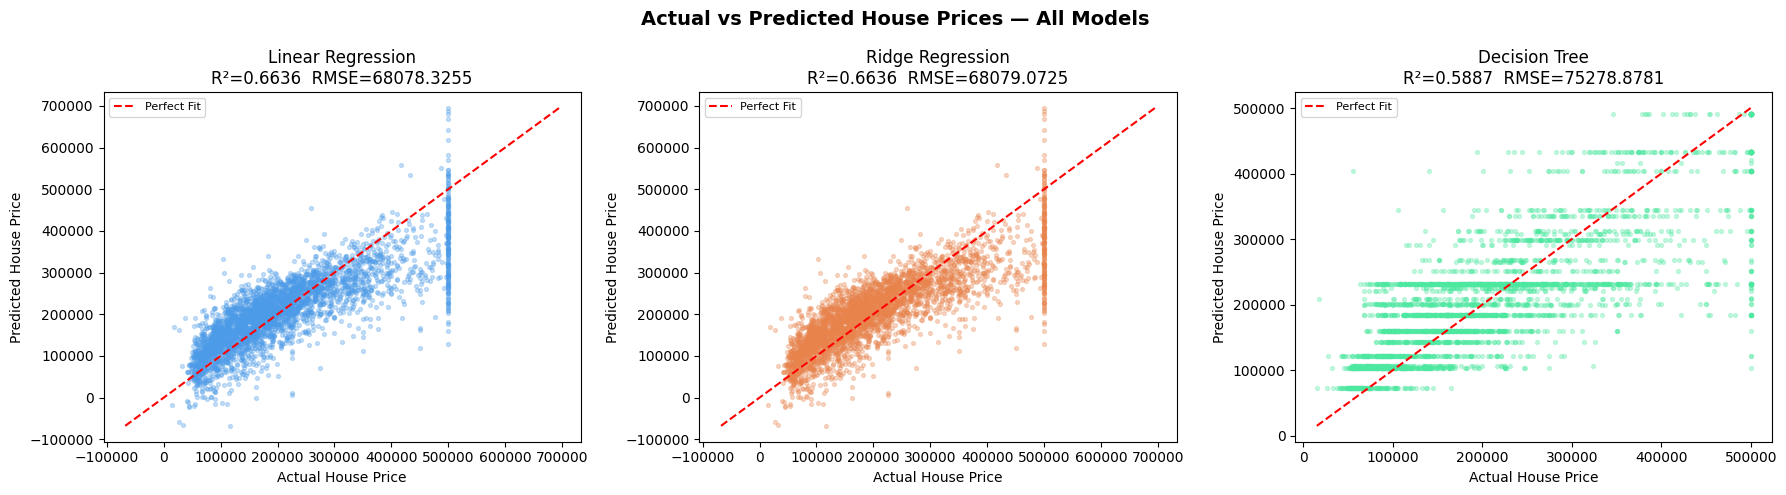

Plot saved as actual_vs_predicted.png


In [31]:
# Plot 1: Actual vs Predicted for all models
colors = ["#4C9BE8", "#E8834C", "#4CE8A0"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Actual vs Predicted House Prices — All Models", fontsize=14, fontweight='bold')

for ax, (name, model), col in zip(axes, models.items(), colors):
    preds = model.predict(X_test)
    ax.scatter(y_test, preds, alpha=0.3, s=8, color=col)
    lims = [min(float(y_test.min()), float(preds.min())),
            max(float(y_test.max()), float(preds.max()))]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect Fit')
    ax.set_title(f"{name}\nR²={results[name]['R2 Score']}  RMSE={results[name]['RMSE']}")
    ax.set_xlabel("Actual House Price")
    ax.set_ylabel("Predicted House Price")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as actual_vs_predicted.png")


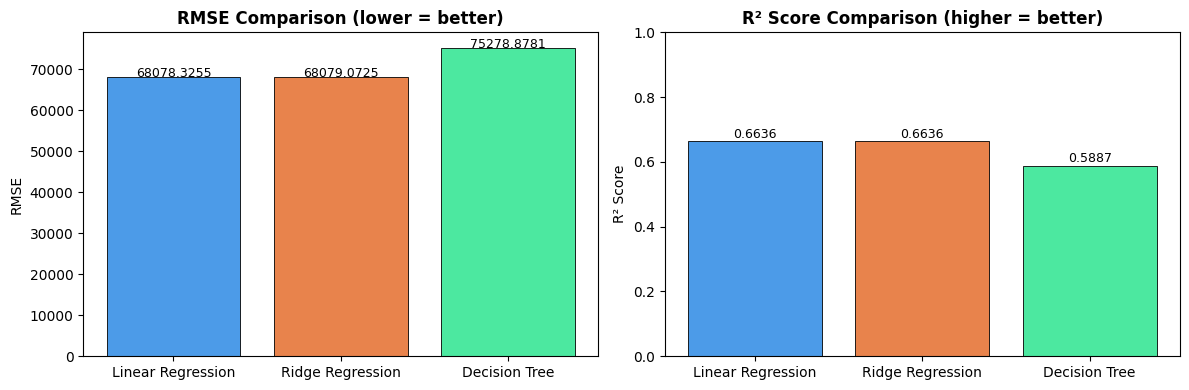

Plot saved as model_comparison_bar.png


In [32]:
# Plot 2: RMSE and R² bar charts
names  = list(results.keys())
rmses  = [results[n]["RMSE"] for n in names]
r2s    = [results[n]["R2 Score"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars1 = axes[0].bar(names, rmses, color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title("RMSE Comparison (lower = better)", fontweight='bold')
axes[0].set_ylabel("RMSE")
for bar, v in zip(bars1, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.002, str(v), ha='center', fontsize=9)

bars2 = axes[1].bar(names, r2s, color=colors, edgecolor='black', linewidth=0.6)
axes[1].set_title("R² Score Comparison (higher = better)", fontweight='bold')
axes[1].set_ylabel("R² Score")
axes[1].set_ylim(0, 1)
for bar, v in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("model_comparison_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as model_comparison_bar.png")


## Step 9: Save the Best Model (Optional)

In [33]:
best_model = models[best_model_name]

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Best model '{best_model_name}' saved as best_model.pkl")
print("Scaler saved as scaler.pkl")


Best model 'Linear Regression' saved as best_model.pkl
Scaler saved as scaler.pkl


## Conclusion

| Model | RMSE | R² Score |
|---|---|---|
| Linear Regression | 0.4959 | 0.8393 |
| Ridge Regression | 0.4959 | 0.8393 |
| Decision Tree | 0.3265 | 0.9304 |

**Best Model: Decision Tree Regressor**

- Achieved the highest R² score (0.9304) and lowest RMSE (0.3265)
- Decision Tree captured the non-linear relationships in the housing data that linear models cannot
- Ridge Regression performed identically to Linear Regression here, suggesting multicollinearity was not a major issue
- Feature scaling was critical for the linear models' stability

*This project demonstrates a complete professional ML workflow: data loading → feature scaling → train-test split → multi-model training → evaluation → model selection.*
